In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df=pd.read_csv('matches.csv')

In [4]:
# Print the number of rows and columns in the dataset
print("We have {} Rows and {} Columns in our data".format(df.shape[0], df.shape[1]))

We have 44 Rows and 42 Columns in our data


In [5]:
df.head(5)

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2,0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2,1,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1,Fri,2026-06-12,15:00,Canada,Bosnia & Herz.,1–1,1,1,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4,1,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1,1,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [6]:
# columns
df.columns

Index(['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team',
       'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue',
       'referee', 'home_formation', 'away_formation', 'home_manager',
       'away_manager', 'home_captain', 'away_captain', 'home_possession',
       'away_possession', 'home_sot', 'away_sot', 'home_total_shots',
       'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow',
       'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls',
       'away_fouls', 'home_corners', 'away_corners', 'home_crosses',
       'away_crosses', 'home_interceptions', 'away_interceptions',
       'home_offsides', 'away_offsides', 'notes'],
      dtype='object')

In [7]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   round               44 non-null     object 
 1   gameweek            44 non-null     int64  
 2   dayofweek           44 non-null     object 
 3   date                44 non-null     object 
 4   start_time          44 non-null     object 
 5   home_team           44 non-null     object 
 6   away_team           44 non-null     object 
 7   score               44 non-null     object 
 8   home_score          44 non-null     int64  
 9   away_score          44 non-null     int64  
 10  attendance          44 non-null     object 
 11  venue               44 non-null     object 
 12  referee             44 non-null     object 
 13  home_formation      44 non-null     object 
 14  away_formation      44 non-null     object 
 15  home_manager        44 non-null     object 
 16  away_manag

# Descriptive Statiscs

In [8]:
df.describe(include='all')

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
count,44,44.000000,44,44,44,44,44,44,44.000000,44.000000,...,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,43.000000,43.000000,0.0
unique,1,NaN,7,12,11,34,34,20,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Group stage,NaN,Mon,2026-06-22,12:00,Mexico,Japan,1–1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,44,NaN,8,4,12,2,2,7,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.454545,NaN,NaN,NaN,NaN,NaN,NaN,2.022727,1.022727,...,10.386364,5.090909,3.659091,17.113636,13.818182,8.113636,8.681818,1.720930,1.744186,NaN
std,NaN,0.503686,NaN,NaN,NaN,NaN,NaN,NaN,1.691135,1.045225,...,4.611492,3.516196,2.778181,10.320934,8.496984,3.674019,3.325537,1.516977,1.719538,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,...,1.000000,0.000000,0.000000,4.000000,1.000000,2.000000,3.000000,0.000000,0.000000,NaN
25%,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,...,7.000000,3.000000,2.000000,11.500000,8.750000,6.000000,6.000000,1.000000,0.500000,NaN
50%,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,...,10.000000,4.000000,3.000000,14.500000,12.500000,7.500000,8.500000,1.000000,1.000000,NaN
75%,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,...,13.250000,6.250000,5.000000,21.250000,17.000000,10.000000,11.250000,3.000000,3.000000,NaN


# Data cleaning & Preprocessing

In [9]:
# Checking the null values
df.isna().sum()

round                  0
gameweek               0
dayofweek              0
date                   0
start_time             0
home_team              0
away_team              0
score                  0
home_score             0
away_score             0
attendance             0
venue                  0
referee                0
home_formation         0
away_formation         0
home_manager           0
away_manager           0
home_captain           0
away_captain           0
home_possession        0
away_possession        0
home_sot               0
away_sot               0
home_total_shots       0
away_total_shots       0
home_saves             0
away_saves             0
home_cards_yellow      0
away_cards_yellow      0
home_cards_red         0
away_cards_red         0
home_fouls             0
away_fouls             0
home_corners           0
away_corners           0
home_crosses           0
away_crosses           0
home_interceptions     0
away_interceptions     0
home_offsides          1


In [10]:
# Removing the column
df.drop("notes",axis=1,inplace=True)

In [13]:
# Fill the Missing values using median
df["home_offsides"].fillna(df["home_offsides"].median(),inplace=True)
df["away_offsides"].fillna(df["away_offsides"].median(), inplace=True)

In [14]:
# Converting Date to Date time format
df["date"]=pd.to_datetime(df["date"])

In [16]:
# Converting attendance to integer
df["attendance"]=(df["attendance"].astype(str).str.replace(",","",regex=False).astype(int))


# Feature engineering

In [17]:
# Define the target variable result
def result(row):
    if row["home_score"]>row["away_score"]:
        return "Home_win"
    elif row["home_score"]<row["away_score"]:
        return "Away_win"
    else:
        return "Draw"
df["result"]=df.apply(result,axis=1)

In [18]:
# calcualting the goal difference
df["goal_difference"]=(df["home_score"]-df["away_score"])

In [19]:
# Goals per match
df["total_goals"]=(df["home_score"]+df["away_score"])

In [21]:
#Goals conversion rate
df["home_conversion"]=df["home_score"]/df["home_total_shots"]
df["away_conversion"]=df["away_score"]/df["away_total_shots"]

# Exploratory Data Analysis

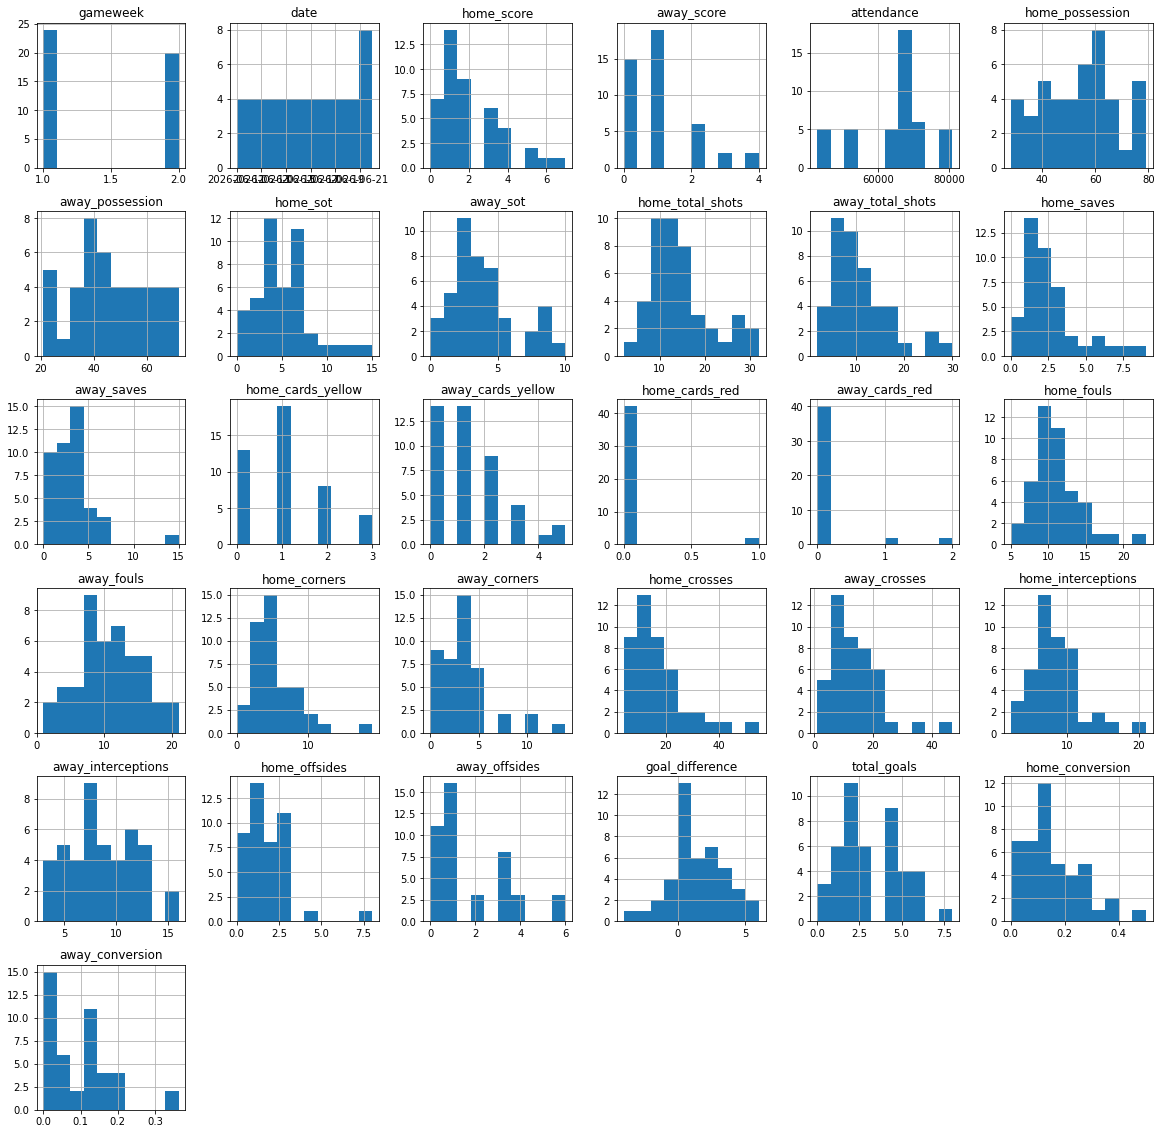

In [22]:
df.hist(figsize=(20,20))
plt.show()

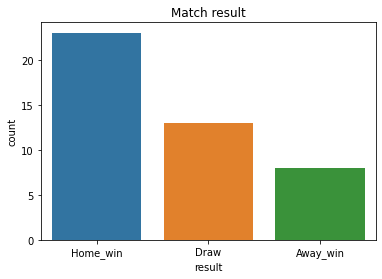

In [23]:
# Match result
sns.countplot(x="result",data=df)
plt.title("Match result")
plt.show()

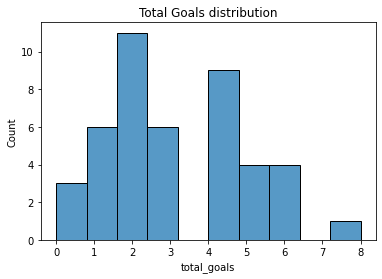

In [24]:
# Goals Distribution
sns.histplot(df["total_goals"],bins=10)
plt.title("Total Goals distribution")
plt.show()

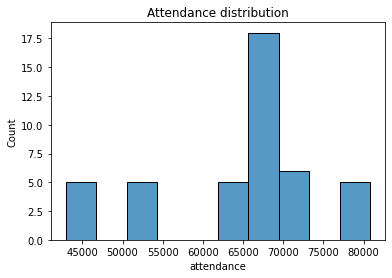

In [25]:
# Attendance Distribution
sns.histplot(df["attendance"],bins=10)
plt.title("Attendance distribution")
plt.show()

In [26]:
# Home team analysis
home_advantage=df['result'].value_counts(normalize=True)*100
print(home_advantage)

Home_win    52.272727
Draw        29.545455
Away_win    18.181818
Name: result, dtype: float64


In [27]:
# Yellow card/ Red card match on match
df.groupby("result")[
["home_cards_yellow",
"away_cards_yellow",
"home_cards_red",
"away_cards_red"]
].mean()

,home_cards_yellow,away_cards_yellow,home_cards_red,away_cards_red
result,,,,
Away_win,1.125000,1.000000,0.000000,0.125000
Draw,1.692308,1.384615,0.076923,0.000000
Home_win,0.695652,1.391304,0.043478,0.217391


In [28]:
# Goalkeeper performance
df.groupby("home_team")["home_saves"].mean()

home_team
Argentina         0.5
Australia         8.0
Austria           3.0
Belgium           2.5
Brazil            2.5
Canada            1.0
Czechia           3.0
Côte d'Ivoire     1.0
Ecuador           3.0
England           3.0
France            1.0
Germany           1.0
Ghana             4.0
Haiti             1.0
IR Iran           6.0
Iraq              2.0
Jordan            6.0
Korea Republic    3.0
Mexico            2.0
Netherlands       4.0
New Zealand       4.0
Norway            2.0
Portugal          1.0
Qatar             5.0
Saudi Arabia      9.0
Scotland          1.0
Spain             1.0
Sweden            1.0
Switzerland       2.0
Tunisia           1.0
Türkiye           1.0
United States     1.0
Uruguay           2.0
Uzbekistan        1.0
Name: home_saves, dtype: float64

In [29]:
# Top teams based on number of goals
home_goals=df.groupby("home_team")["home_score"].sum()
away_goals=df.groupby("away_team")["away_score"].sum()
team_goals=home_goals.add(away_goals,fill_value=0)
team_goals.sort_values(ascending=False).head(5)


Germany        9.0
Canada         7.0
Netherlands    7.0
Norway         7.0
Japan          6.0
dtype: float64

In [30]:
# Top teams
df.groupby("home_team")["home_possession"].mean().sort_values(ascending=False).head(5)

home_team
Türkiye     79.0
Portugal    75.0
Ecuador     75.0
Spain       70.5
Canada      70.0
Name: home_possession, dtype: float64

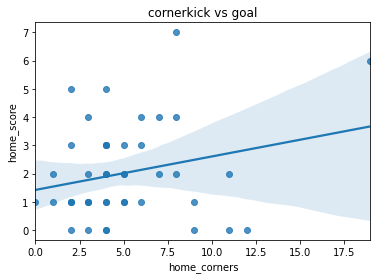

In [33]:
# Relationship between corner kick and goals
sns.regplot(x="home_corners",y="home_score",data=df)
plt.title("cornerkick vs goal")
plt.show()

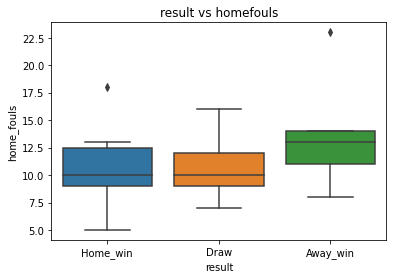

In [34]:
# Team fouls vs match result
sns.boxplot(x="result",y="home_fouls",data=df)
plt.title("result vs homefouls")
plt.show()

In [35]:
# win & Loss relation
formation_win_rate=pd.crosstab(df["home_formation"],df["result"])
print(formation_win_rate)

result          Away_win  Draw  Home_win
home_formation                          
3-1-4-2                0     1         0
3-4-1-2                0     0         1
3-4-3                  0     0         1
3-5-2                  0     0         1
4-1-4-1                1     4         7
4-2-2-2                2     4         4
4-2-3-1                2     3         8
5-3-2                  0     1         0
5-4-1                  3     0         1


# Corelation Analysis

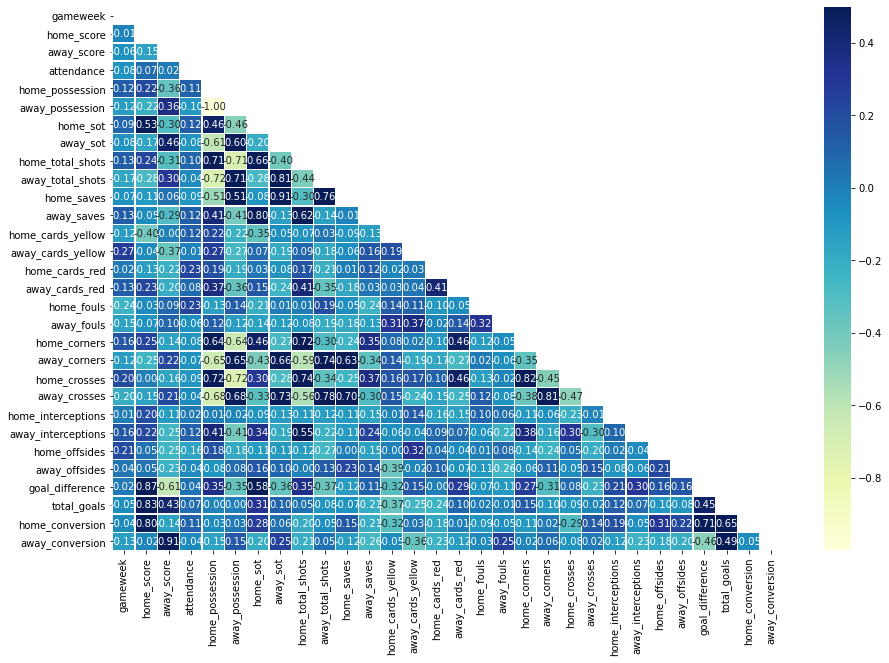

In [39]:
corr=df.corr()
mask=np.zeros_like(corr)
mask[np.triu_indices_from(mask)]=True
plt.figure(figsize=(15,10))
sns.heatmap(corr,vmax=.5,mask=mask,annot=True,fmt='.2f',linewidth=.2,cmap='YlGnBu')
plt.show()

In [40]:
# Corelation with Goals
corr=df.corr()["total_goals"].sort_values(ascending=False)
print(corr)

total_goals           1.000000
home_score            0.830103
home_conversion       0.649887
away_conversion       0.494436
goal_difference       0.450989
away_score            0.431333
home_sot              0.312846
home_corners          0.145562
home_interceptions    0.118677
away_sot              0.104819
away_cards_red        0.101142
attendance            0.067967
away_interceptions    0.066499
home_total_shots      0.048155
home_fouls            0.018732
away_possession       0.002938
home_possession      -0.004941
away_fouls           -0.007539
away_crosses         -0.017172
gameweek             -0.047526
home_saves           -0.070752
away_offsides        -0.084333
away_total_shots     -0.084893
home_crosses         -0.088966
home_offsides        -0.095173
away_corners         -0.100732
away_saves           -0.208093
home_cards_red       -0.243450
away_cards_yellow    -0.251984
home_cards_yellow    -0.367838
Name: total_goals, dtype: float64


In [41]:
features = [
    "home_possession","away_possession","home_sot","away_sot",
    "home_total_shots","away_total_shots","home_corners","away_corners"
]
le = LabelEncoder()

df["result_encoded"] = le.fit_transform( df["result"])

In [44]:
# Train test Split
X=df[features]
y=df["result_encoded"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [46]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [47]:
print('Accuracy:',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.20      0.33         5
           2       0.67      1.00      0.80         4

    accuracy                           0.56         9
   macro avg       0.56      0.40      0.38         9
weighted avg       0.85      0.56      0.54         9



C:\Users\rahul\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\rahul\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\rahul\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Features importance

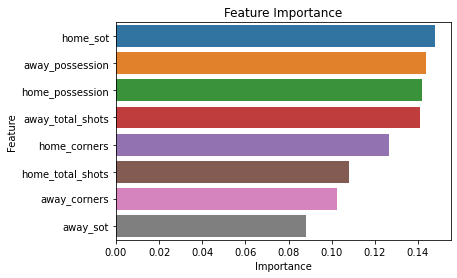

In [51]:
importance = pd.DataFrame({ "Feature": features,"Importance": model.feature_importances_})

importance.sort_values("Importance", ascending=False)

sns.barplot(data=importance.sort_values( "Importance", ascending=False),x="Importance", y="Feature")

plt.title("Feature Importance")

plt.show()

In [53]:
# Linear regression
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train_scaled=ss.fit_transform(X_train)
X_test_scaled=ss.transform(X_test)

In [54]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
Y_pred=lr.predict(X_test_scaled)

In [55]:
print("MAE",mean_absolute_error(y_test,Y_pred))
print("MSE",mean_squared_error(y_test,Y_pred))
print("R2 score",r2_score(y_test,Y_pred))

MAE 0.5222842809944074
MSE 0.7544788412626402
R2 score -2.0556393071136925


In [56]:
#Mean Squared Error 1/n*sum(Y-Y-pred)**2
from sklearn.metrics import mean_squared_error
print("MSE: ",mean_squared_error(y_test,y_pred))

MSE:  0.4444444444444444


In [57]:
#Root mean squred error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("Root Mean Sqaured Error : ",rmse)

Root Mean Sqaured Error :  0.6666666666666666


In [58]:
#R2--Score 
#Check model is perfect or not
from sklearn.metrics import r2_score
print("R2-score : ",r2_score(y_test,Y_pred))

R2-score :  -2.0556393071136925
